Simulaciones numéricas del modelo huésped-vector para el dengue.


Genera tres figuras:
  1. fig_temporal_dengue.pdf  – evolución temporal R0=0.8 y R0=2.4
  2. fig_bifurcacion_dengue.pdf – diagrama de bifurcación
  3. fig_estacional_dengue.pdf  – modelo con estacionalidad vectorial


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros

In [17]:
BETA_H  = 0.375          # Transmisión vector → humano (día⁻¹)
BETA_V  = 0.375          # Transmisión humano → vector (día⁻¹)
GAMMA_H = 1/7            # Recuperación humana ≈ 7 días (día⁻¹)
MU_H    = 1/(70*365)     # Mortalidad humana (esperanza de vida 70 años)
MU_V    = 1/14           # Mortalidad del mosquito (vida media 14 días)
NH      = 1e5            # Población humana

# Función R0

In [18]:
def R0(ratio_VH, beta_h=BETA_H, beta_v=BETA_V,
       mu_v=MU_V, gamma_h=GAMMA_H, mu_h=MU_H):
    return np.sqrt(beta_h * beta_v * ratio_VH / (mu_v * (gamma_h + mu_h)))

# Modelo autónomo


In [19]:
def dengue_autonomo(t, y, beta_h, beta_v, gamma_h, mu_h, mu_v, NH, NV0):
    SH, IH, SV, IV = y
    Lambda_V = mu_v * NV0
    dSH = mu_h * NH - beta_h * (IV / NH) * SH - mu_h * SH
    dIH = beta_h * (IV / NH) * SH - (gamma_h + mu_h) * IH
    dSV = Lambda_V - beta_v * (IH / NH) * SV - mu_v * SV
    dIV = beta_v * (IH / NH) * SV - mu_v * IV
    return [dSH, dIH, dSV, dIV]

# Modelo estacional

In [20]:
def dengue_estacional(t, y, beta_h, beta_v, gamma_h, mu_h, mu_v, NH, NV0,
                      eps=0.6, phi=np.pi/2):
    SH, IH, SV, IV = y
    Lambda_V = mu_v * NV0 * (1 + eps * np.cos(2 * np.pi * t / 365 - phi))
    dSH = mu_h * NH - beta_h * (IV / NH) * SH - mu_h * SH
    dIH = beta_h * (IV / NH) * SH - (gamma_h + mu_h) * IH
    dSV = Lambda_V - beta_v * (IH / NH) * SV - mu_v * SV
    dIV = beta_v * (IH / NH) * SV - mu_v * IV
    return [dSH, dIH, dSV, dIV]

# Condiciones iniciales

In [21]:
def y0_dle(NV0):
    """Condiciones iniciales: casi todo en E0, pequeña perturbación."""
    IH0 = 10
    IV0 = 50
    return [NH - IH0, IH0, NV0 - IV0, IV0]

# Figura 1: Evolución temporal

fig_temporal_dengue.png guardado.
fig_temporal_dengue.pdf guardado.


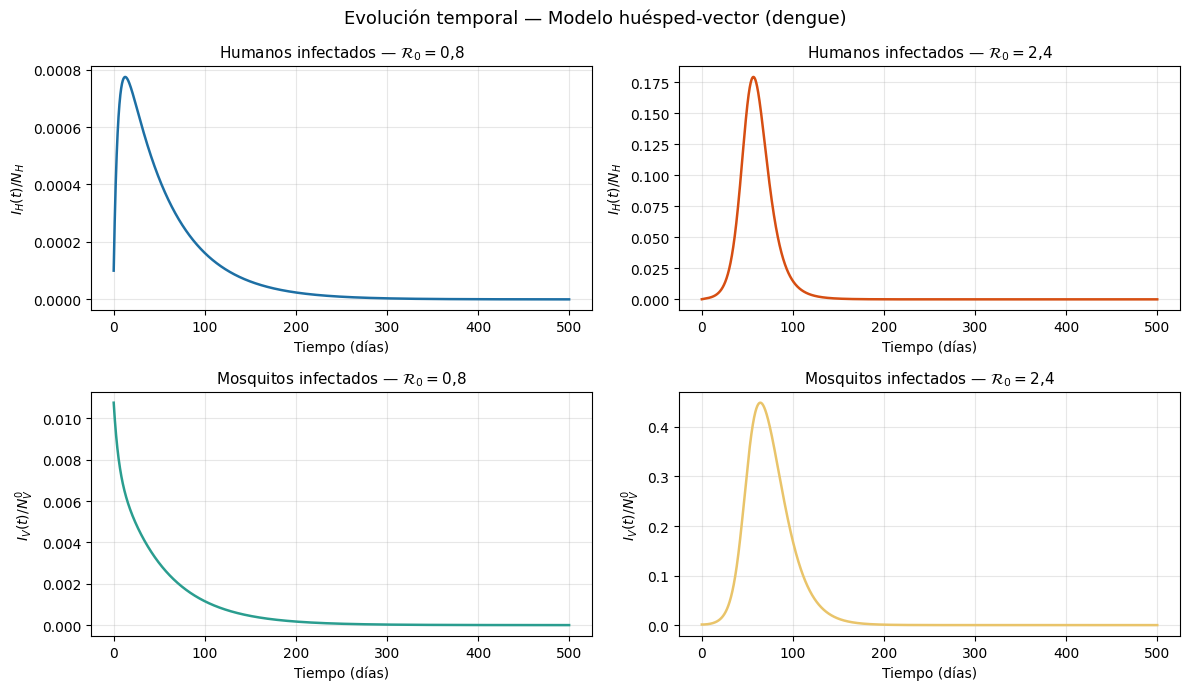

In [22]:
t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)
escenarios = [("$\\mathcal{R}_0 = 0{,}8$", 0.8), ("$\\mathcal{R}_0 = 2{,}4$", 2.4)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Evolución temporal — Modelo huésped-vector (dengue)", fontsize=13)

colors_h = ["#1d6fa4", "#d64e12"]   # azul, naranja
colors_v = ["#2a9d8f", "#e9c46a"]   # verde, amarillo

for col, (label, r0_target) in enumerate(escenarios):
    # Calculamos NV0 para obtener ese R0
    ratio = (r0_target**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V)
    NV0 = ratio * NH
    y0 = y0_dle(NV0)
    args = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0)
    sol = solve_ivp(dengue_autonomo, t_span, y0, t_eval=t_eval, args=args,
                    method="RK45", rtol=1e-8, atol=1e-10)

    ax_h = axes[0, col]
    ax_v = axes[1, col]

    IH_frac = sol.y[1] / NH
    IV_frac = sol.y[3] / NV0

    ax_h.plot(sol.t, IH_frac, color=colors_h[col], lw=1.8)
    ax_h.set_title(f"Humanos infectados — {label}", fontsize=11)
    ax_h.set_xlabel("Tiempo (días)")
    ax_h.set_ylabel("$I_H(t)/N_H$")
    ax_h.grid(True, alpha=0.3)

    ax_v.plot(sol.t, IV_frac, color=colors_v[col], lw=1.8)
    ax_v.set_title(f"Mosquitos infectados — {label}", fontsize=11)
    ax_v.set_xlabel("Tiempo (días)")
    ax_v.set_ylabel("$I_V(t)/N_V^0$")
    ax_v.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_temporal_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_temporal_dengue.png", dpi=150, bbox_inches="tight")

print("fig_temporal_dengue.png guardado.")
print("fig_temporal_dengue.pdf guardado.")

plt.show()

# Figura 2: Diagrama de bifurcación

 fig_bifurcacion_dengue.pdf guardado.
 fig_bifurcacion_dengue.png guardado.


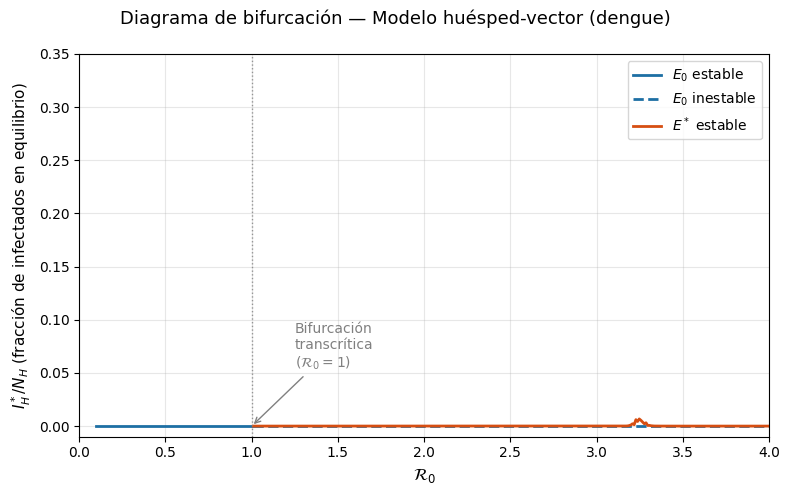

In [23]:
R0_vec = np.linspace(0.1, 4.0, 400)
IH_eq  = np.zeros_like(R0_vec)

t_eq = (0, 5000)   # integrar hasta estado estacionario
t_eval_eq = np.array([5000])

for i, r0 in enumerate(R0_vec):
    ratio = (r0**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V)
    NV0 = ratio * NH
    y0 = y0_dle(NV0)
    args = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0)
    try:
        sol = solve_ivp(dengue_autonomo, t_eq, y0, t_eval=t_eval_eq, args=args,
                        method="RK45", rtol=1e-9, atol=1e-11, dense_output=False)
        IH_eq[i] = sol.y[1, -1] / NH
    except Exception:
        IH_eq[i] = np.nan

IH_eq = np.where(IH_eq < 1e-7, 0.0, IH_eq)

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Diagrama de bifurcación — Modelo huésped-vector (dengue)", fontsize=13)

mask_dle  = R0_vec <= 1.0
mask_end  = R0_vec >= 1.0

ax.plot(R0_vec[mask_dle], np.zeros(mask_dle.sum()),
        color="#1d6fa4", lw=2.0, label="$E_0$ estable")
ax.plot(R0_vec[mask_end], np.zeros(mask_end.sum()),
        color="#1d6fa4", lw=2.0, ls="--", label="$E_0$ inestable")
ax.plot(R0_vec[mask_end], IH_eq[mask_end],
        color="#d64e12", lw=2.0, label="$E^*$ estable")
ax.axvline(x=1.0, color="gray", lw=1.0, ls=":", alpha=0.8)
ax.annotate("Bifurcación\ntranscrítica\n($\\mathcal{R}_0=1$)",
            xy=(1.0, 0.0), xytext=(1.25, 0.055),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10, color="gray")
ax.set_xlabel("$\\mathcal{R}_0$", fontsize=12)
ax.set_ylabel("$I_H^*/N_H$ (fracción de infectados en equilibrio)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4.0)
ax.set_ylim(-0.01, 0.35)

plt.tight_layout()
plt.savefig("fig_bifurcacion_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_bifurcacion_dengue.png", dpi=150, bbox_inches="tight")

print(" fig_bifurcacion_dengue.pdf guardado.")
print(" fig_bifurcacion_dengue.png guardado.")

plt.show()

# Figura 3: Estacionalidad

 fig_estacional_dengue.pdf guardado.
 fig_estacional_dengue.png guardado.


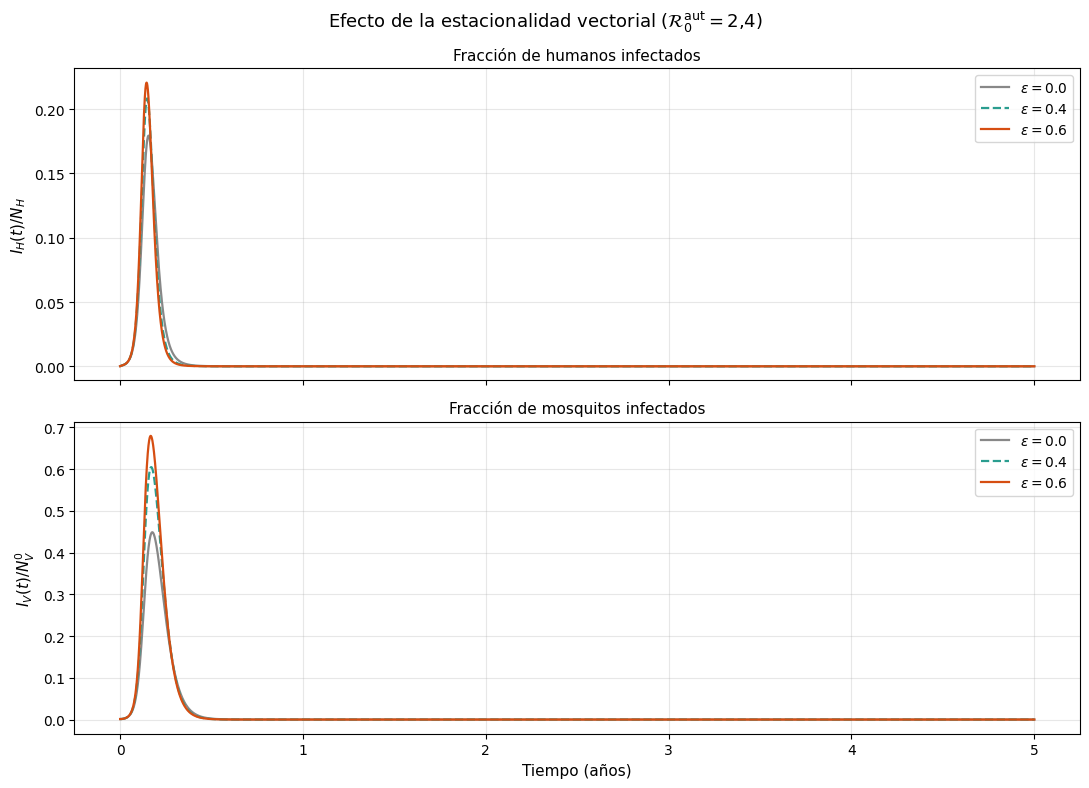

R0 con parámetros base y ratio NV/NH=2: 5.249


In [24]:
r0_est = 2.4
ratio  = (r0_est**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V)
NV0    = ratio * NH

t_span_est = (0, 5*365)
t_eval_est = np.linspace(0, 5*365, 10000)
y0_est = y0_dle(NV0)

eps_list = [0.0, 0.4, 0.6]
colores  = ["#888888", "#2a9d8f", "#d64e12"]
estilos  = ["-", "--", "-"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle("Efecto de la estacionalidad vectorial ($\\mathcal{R}_0^{\\mathrm{aut}}=2{,}4$)",
             fontsize=13)

for eps, color, ls in zip(eps_list, colores, estilos):
    args_est = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0, eps, np.pi/2)
    sol = solve_ivp(dengue_estacional, t_span_est, y0_est, t_eval=t_eval_est,
                    args=args_est, method="RK45", rtol=1e-8, atol=1e-10)
    t_yr = sol.t / 365
    IH_f = sol.y[1] / NH
    IV_f = sol.y[3] / NV0
    lbl  = f"$\\varepsilon = {eps}$"
    ax1.plot(t_yr, IH_f, color=color, lw=1.6, ls=ls, label=lbl)
    ax2.plot(t_yr, IV_f, color=color, lw=1.6, ls=ls, label=lbl)

ax1.set_ylabel("$I_H(t)/N_H$", fontsize=11)
ax1.set_title("Fracción de humanos infectados", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_ylabel("$I_V(t)/N_V^0$", fontsize=11)
ax2.set_xlabel("Tiempo (años)", fontsize=11)
ax2.set_title("Fracción de mosquitos infectados", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_estacional_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_estacional_dengue.png", dpi=150, bbox_inches="tight")

print(" fig_estacional_dengue.pdf guardado.")
print(" fig_estacional_dengue.png guardado.")

plt.show()

print(f"R0 con parámetros base y ratio NV/NH=2: {R0(2):.3f}")